*   Notebook Author - Chathila Wijesinghe



In [ ]:
#Importing pandas library
import pandas as pd

#Importing numpy library
import numpy as np

#Importing plotly
import plotly.express as px

import matplotlib.pyplot as plt

# To transform your features into new values
from sklearn import preprocessing

# Import train_test_split function
from sklearn.model_selection import train_test_split

#Import scikit-learn metrics module for classification and regression performance metrics
from sklearn import metrics

# To create and plot the confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# To produce the classification metrics report
from sklearn.metrics import classification_report

# To create, calculate and plot the RoC curve
from sklearn.metrics import RocCurveDisplay

# To transform your features into new values
from sklearn.preprocessing import StandardScaler

# Import GridSearchCV for hyperparameter tuning using cross-validation
from sklearn.model_selection import GridSearchCV

# Import Logistic Regression model for binary classification
from sklearn.linear_model import LogisticRegression
# Import K-Nearest Neighbors classifier for distance-based classification
from sklearn.neighbors import KNeighborsClassifier

#initiate a new ensemble model
from sklearn.ensemble import VotingClassifier

#Loading data into a DataFrame
dataset=pd.read_csv('/content/classification_loan_data.csv')

Tutorial 3 & 4

In [ ]:
# All training data except the target column
X = dataset.drop(["loan_approval_status"], axis = 1)
# select target variable to model, loan_approval_status
y = dataset['loan_approval_status']

#split dataset into train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,

                                                    random_state=42, stratify=y)
# Initialize scaler to standardize features
scaler = StandardScaler()

# scaled train/test dataset
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Tutorial 3 & 4

In [ ]:
# Logistic Regression Model

# instantiate the LR model (using the default parameters)
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr=lr.predict(X_test_scaled)

# KNN model

# instantiate the KNN model (using the default parameters)
knn = KNeighborsClassifier(n_neighbors=24)
knn.fit(X_train_scaled, y_train)
y_pred_knn=knn.predict(X_test_scaled)

Tutorial 3 & 4

In [ ]:
# Base learner's classification report

print("============= Classification Report: LR ==============\n")
print(classification_report(y_test, y_pred_lr))

print("\n============= Classification Report: KNN =============\n")
print(classification_report(y_test, y_pred_knn))

============= Classification Report: LR ==============

              precision    recall  f1-score   support

           0       0.97      0.79      0.87     10028
           1       0.39      0.83      0.53      1666

    accuracy                           0.79     11694
   macro avg       0.68      0.81      0.70     11694
weighted avg       0.88      0.79      0.82     11694


============= Classification Report: KNN =============

              precision    recall  f1-score   support

           0       0.92      0.99      0.96     10028
           1       0.87      0.52      0.65      1666

    accuracy                           0.92     11694
   macro avg       0.90      0.75      0.80     11694
weighted avg       0.92      0.92      0.91     11694



Tutorial 3 & 4

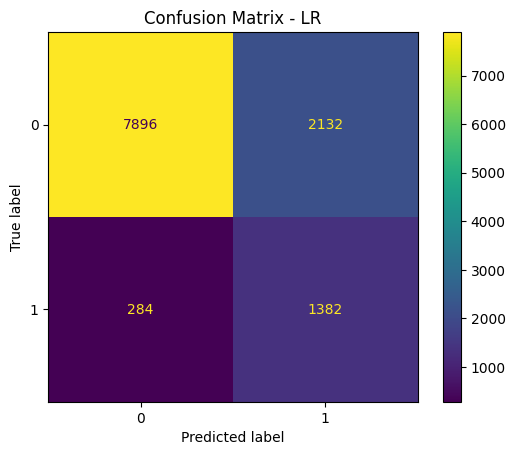

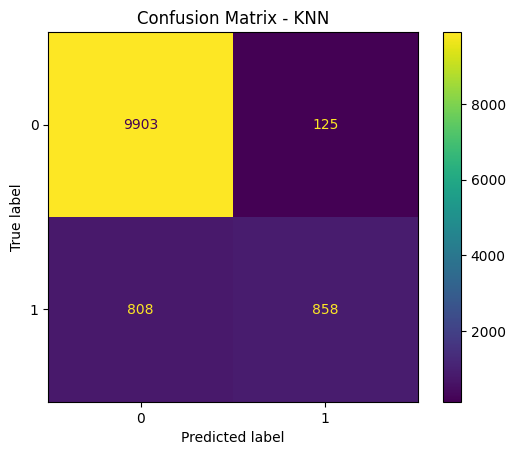

In [ ]:
# Base learner's confusion matrix

# LR confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=lr.classes_)
lr_cm = ConfusionMatrixDisplay(cm_lr,display_labels=lr.classes_)
lr_cm.plot()
plt.title("Confusion Matrix - LR")
plt.show()

# KNN confusion matrix
print("\n")
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=knn.classes_)
knn_cm = ConfusionMatrixDisplay(cm_knn,display_labels=knn.classes_)
knn_cm.plot()
plt.title("Confusion Matrix - KNN")
plt.show()


Tutorial 3 & 4

<Figure size 640x480 with 0 Axes>

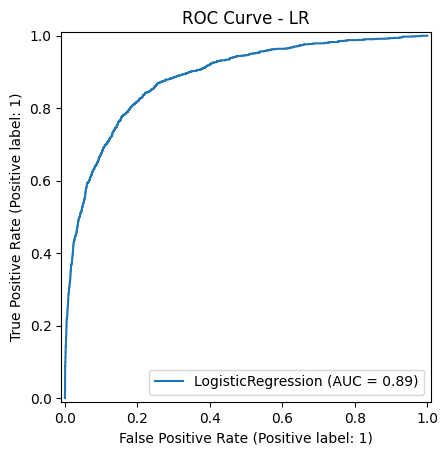

<Figure size 640x480 with 0 Axes>

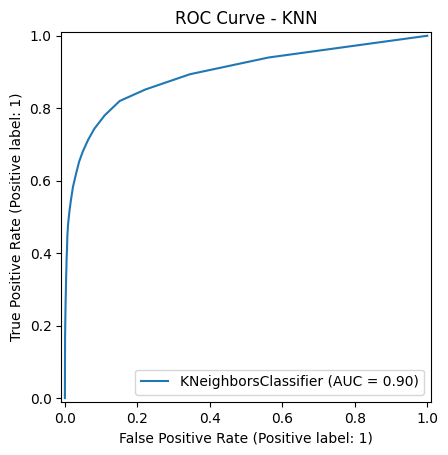

In [ ]:
# Base learner's roc curve

# LR roc curve
plt.figure()
lr_roc = RocCurveDisplay.from_estimator(lr, X_test_scaled, y_test)
plt.title("ROC Curve - LR")
plt.show()

# knn roc curve
plt.figure()
knn_roc = RocCurveDisplay.from_estimator(knn, X_test_scaled, y_test)
plt.title("ROC Curve - KNN")
plt.show()

Tutorial 7

In [ ]:
#create a dictionary of our base learner models
base_learners=[('KNN', knn), ('LR', lr)]

#create our voting classifier, inputting our models
ensemble_learner = VotingClassifier(base_learners, voting='soft')

#fit model to training data
ensemble_learner = ensemble_learner.fit(X_train_scaled, y_train)
y_pred_ensembler = ensemble_learner.predict(X_test_scaled)

Tutorial 7

===== Classification Report: KNN-LR Emsemble Learner =====

              precision    recall  f1-score   support

           0       0.95      0.94      0.95     10028
           1       0.66      0.71      0.69      1666

    accuracy                           0.91     11694
   macro avg       0.81      0.82      0.82     11694
weighted avg       0.91      0.91      0.91     11694





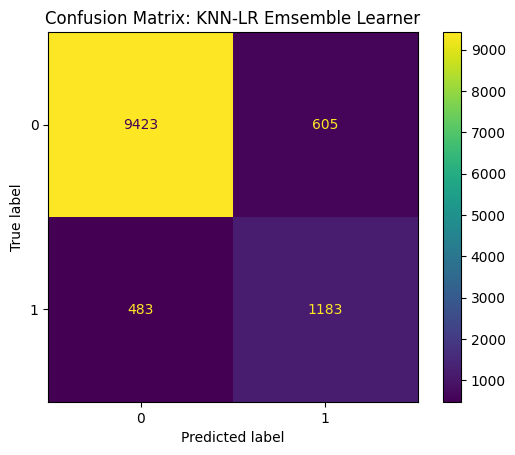

<Figure size 640x480 with 0 Axes>

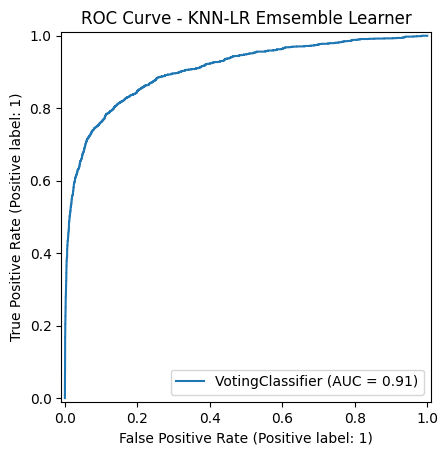

In [ ]:
# Evaluate your ensemble model by generating the classification report and the confusion matrix
from sklearn.metrics import classification_report
print("===== Classification Report: KNN-LR Emsemble Learner =====\n")
print(classification_report(y_test,y_pred_ensembler))

# Construct a confusion matrix
print("\n")
ensemble_learner_cm=confusion_matrix(y_test,y_pred_ensembler)
el_cm=ConfusionMatrixDisplay(confusion_matrix=ensemble_learner_cm,display_labels = ensemble_learner.classes_)
el_cm.plot()
plt.title("Confusion Matrix: KNN-LR Emsemble Learner")
plt.show()

# ensemble_learner roc curve
plt.figure()
el_roc = RocCurveDisplay.from_estimator(ensemble_learner, X_test_scaled, y_test)
plt.title("ROC Curve - KNN-LR Emsemble Learner")
plt.show()

**Case Study (B): Predicting Maximum Loan Amount.**

Tutorial 6

In [ ]:
# To construct and plot decision trees
from sklearn import tree
from matplotlib import pyplot as plt

# Import Decision Tree Regressor to predict maximum loan amount
from sklearn.tree import DecisionTreeRegressor

#Load your prepared dataset as df
df = pd.read_csv('/content/regression_loan_data.csv')

Tutorial 6

In [ ]:
# All training data except the target column
X = df.drop(['max_allowed_loan'], axis=1)
# select target variable to model, max_allowed_loan
y = df['max_allowed_loan']

# Split dataset into train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=10)

Tutorial 6

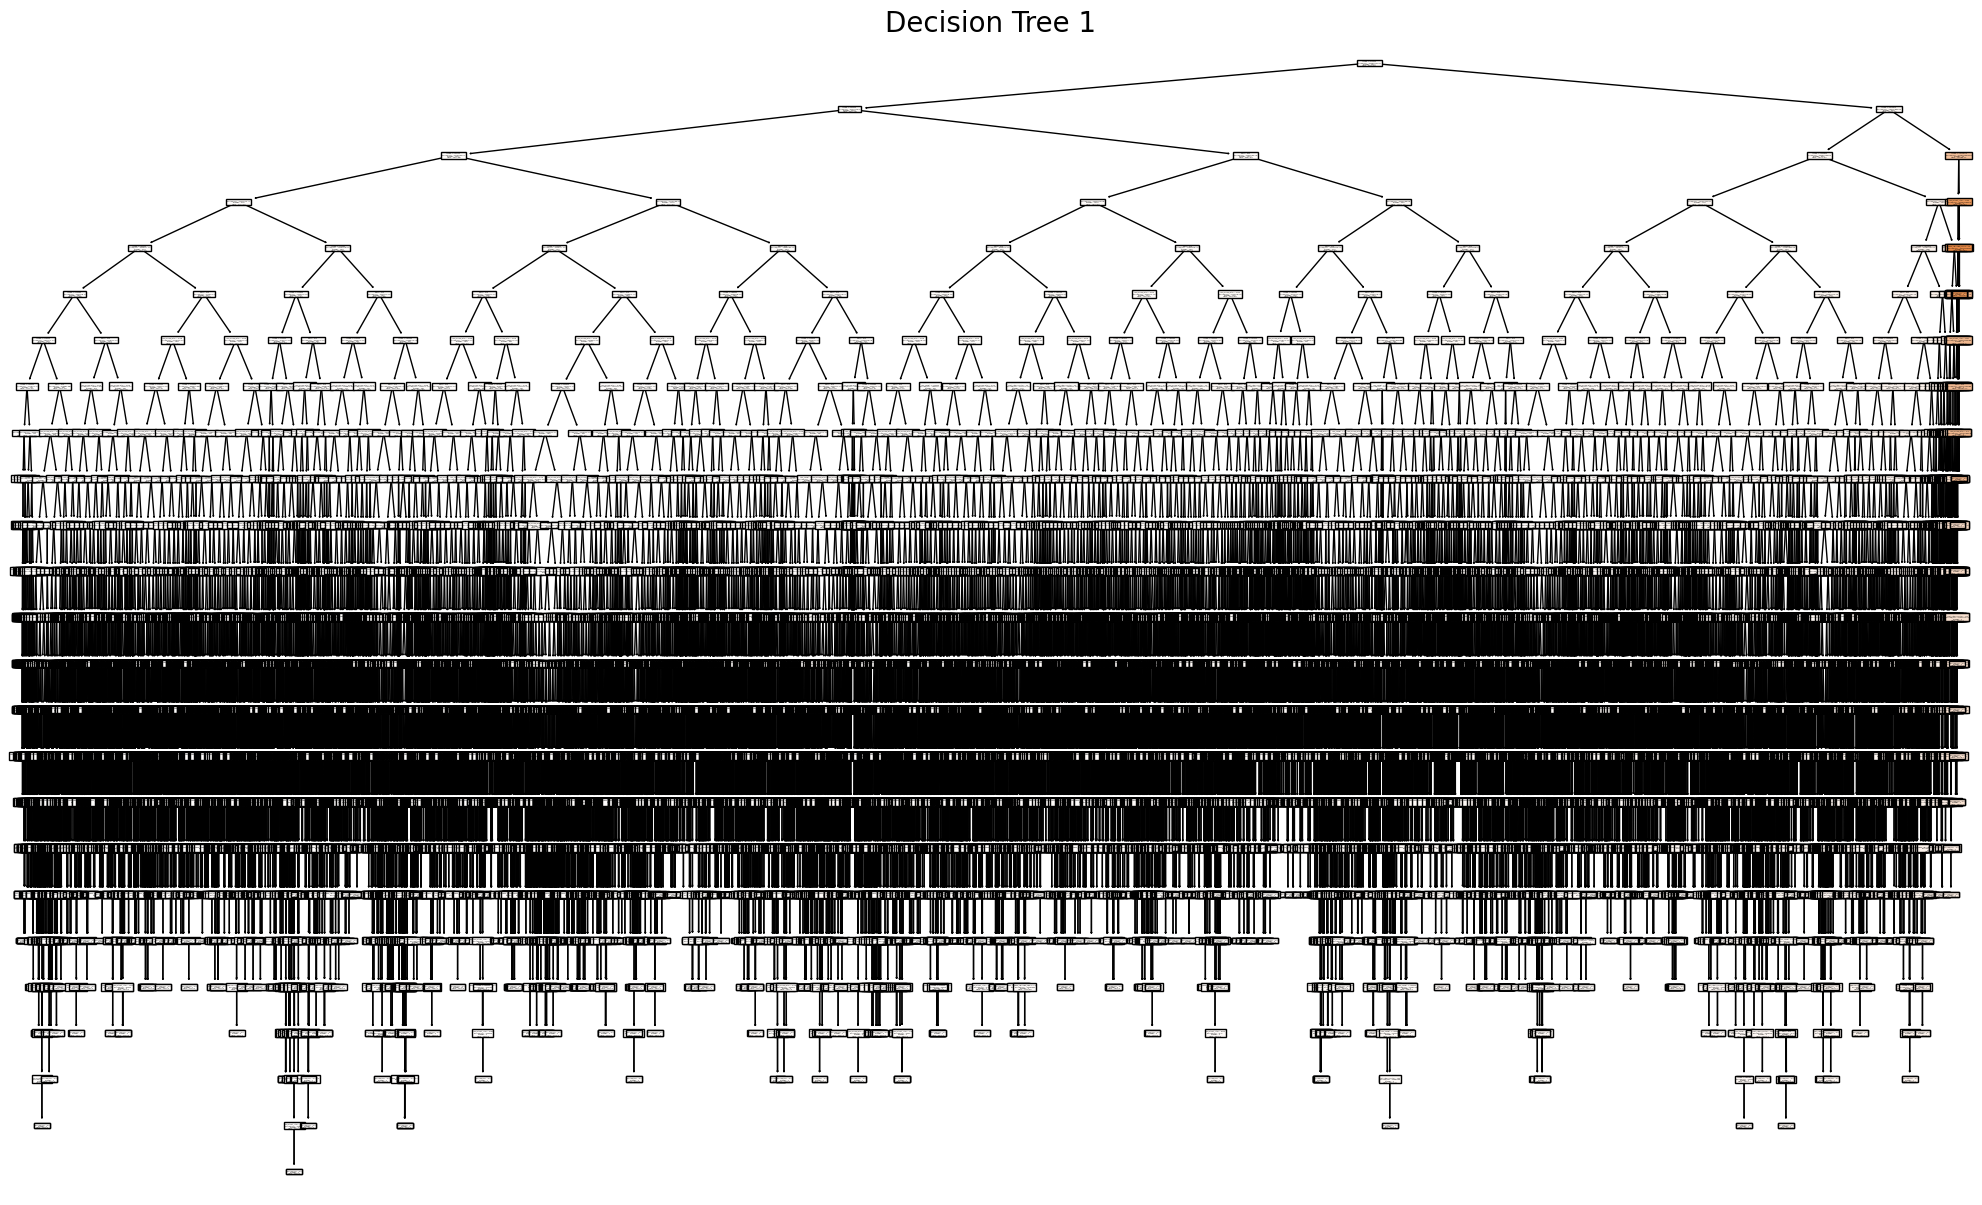

The full Regression Decision Tree Levels:  24


In [ ]:
# To train the algorithm use fit method
DT_1 = DecisionTreeRegressor()
DT_1.fit(X_train, y_train)

# To make predictions on the test set, ues the predict method:
y_pred = DT_1.predict(X_test)

#You can size your plot then plot the fully grown classification tree
DT_1_figure = plt.figure(figsize=(25,15))
DT_1_graph = tree.plot_tree(DT_1, feature_names=list(X_train.columns), filled=True)

plt.title("Decision Tree 1", fontsize=20)
plt.show()

# Display the full tree depth
print("The full Regression Decision Tree Levels: ", DT_1.tree_.max_depth)

#To save the DT_1 graph as svg
DT_1_figure.savefig("DT-1_Figure.svg")
#To save the DT_2 graph as png
DT_1_figure.savefig("DT-1_Figure.png")

Tutorial 6

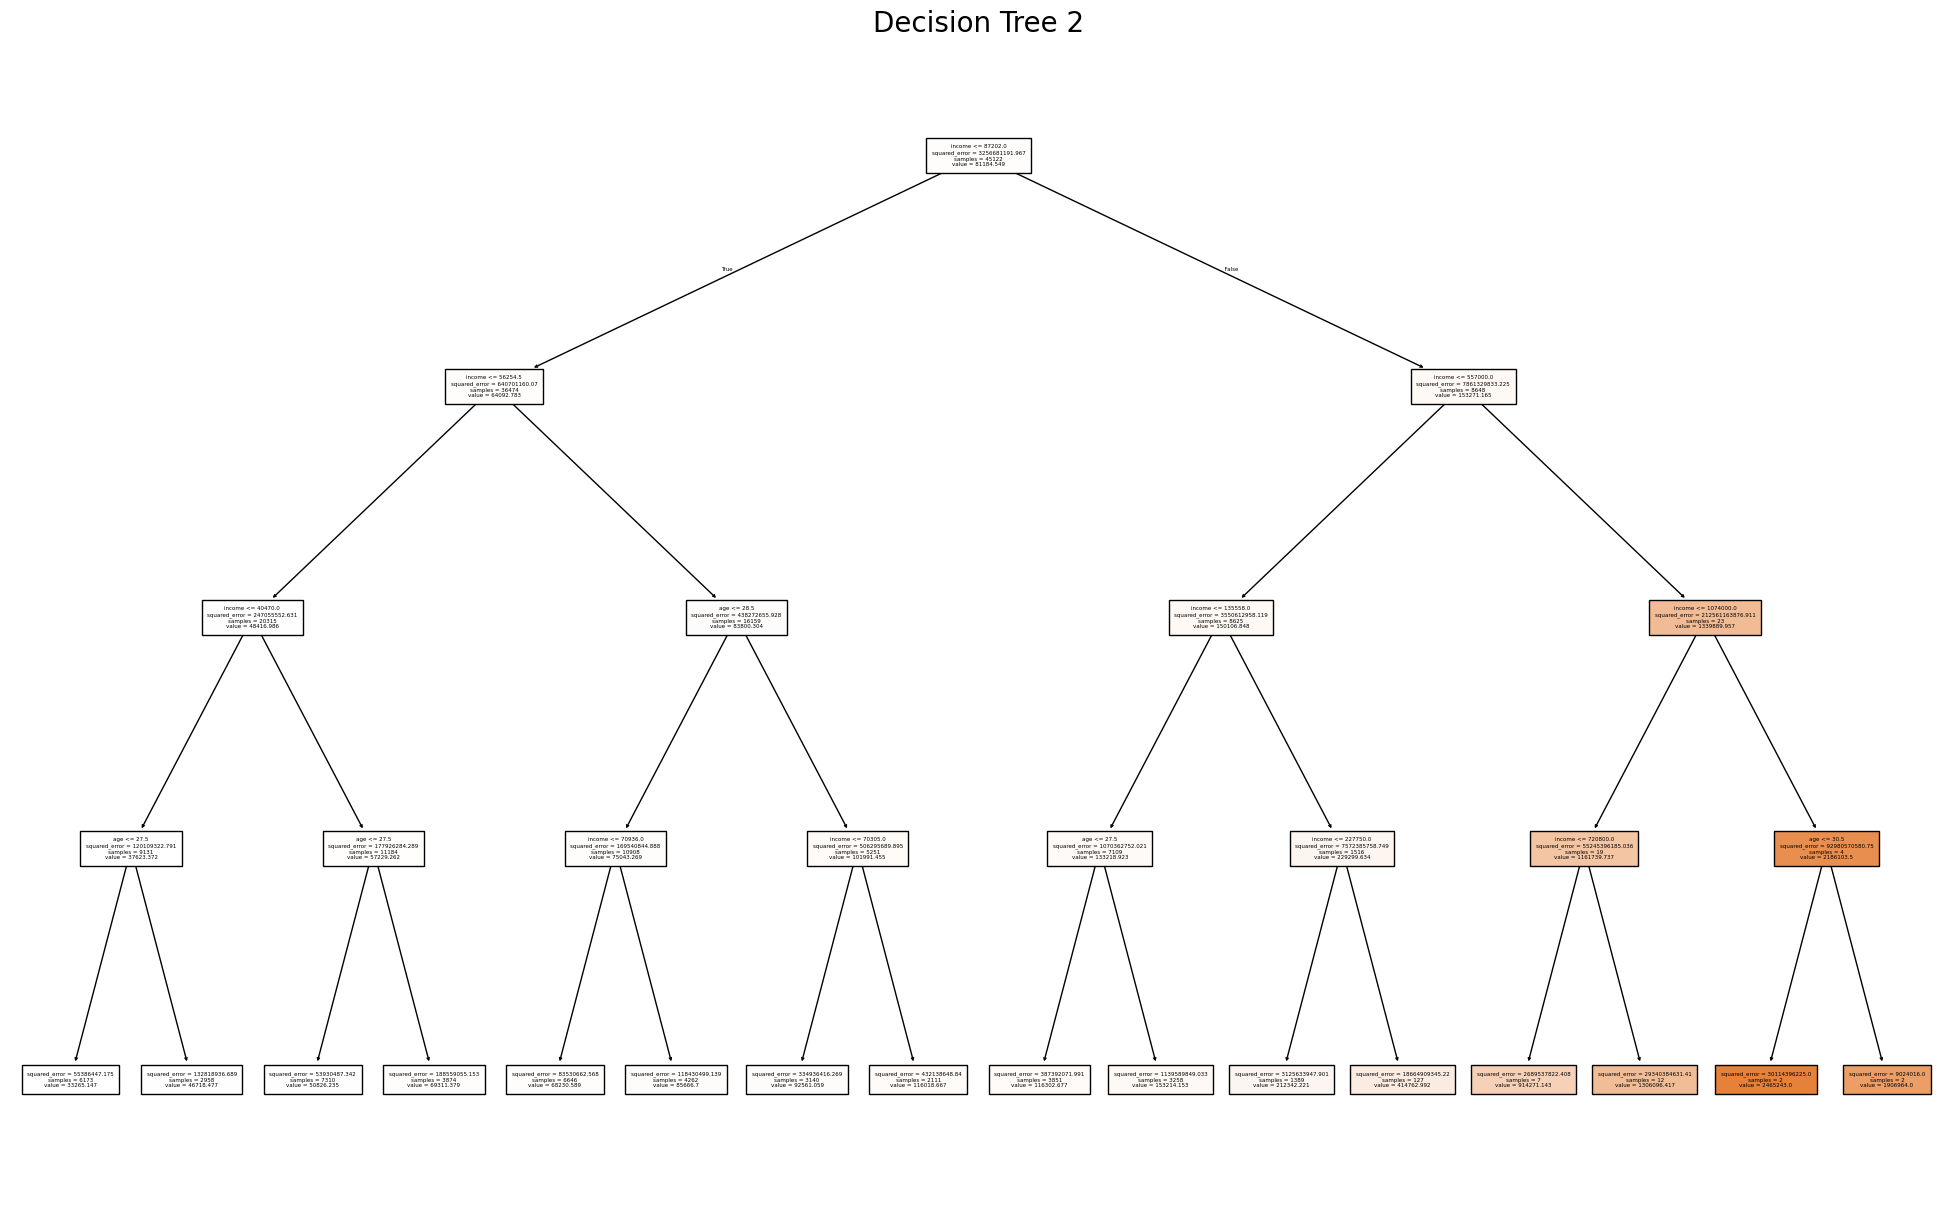

The full Regression Decision Tree Levels:  4


In [ ]:
# Limit the tree growth to 4 levels
DT_2 = DecisionTreeRegressor(max_depth=4)
DT_2.fit(X_train, y_train)

# To make predictions on the test set, ues the predict method:
y_pred_pruned = DT_2.predict(X_test)

#You can size your plot then plot the fully grown classification tree
DT_2_figure = plt.figure(figsize=(25,15))
DT_2_graph = tree.plot_tree(DT_2, feature_names=list(X_train.columns), filled=True, fontsize=4)

plt.title("Decision Tree 2", fontsize=20)
plt.show()

# Display the full tree depth
print("The full Regression Decision Tree Levels: ", DT_2.tree_.max_depth)

#To save the DT_2 graph as svg
DT_2_figure.savefig("DT-2_Figure.svg")
#To save the DT_2 graph as png
DT_2_figure.savefig("DT-2_Figure.png", dpi=300, bbox_inches='tight')

Tutorial 6

In [ ]:
# Calculating the regression metrics for the fully grown regression decision Tree
DT1_mae = metrics.mean_absolute_error(y_test, y_pred)
DT1_mse = metrics.mean_squared_error(y_test, y_pred)
DT1_rmse = np.sqrt(DT1_mse)
DT1_r2 = metrics.r2_score(y_test, y_pred)

print(f"DT-1 Mean Absolute Error: {DT1_mae:,.2f}")
print(f"DT-1 Mean Squared Error: {DT1_mse:,.2f}")
print(f"DT-1 Root Mean Squared Error: {DT1_rmse:,.2f}")
print(f"DT-1 R^2: {DT1_r2:.4f}")

DT-1 Mean Absolute Error: 1,368.92
DT-1 Mean Squared Error: 250,611,451.86
DT-1 Root Mean Squared Error: 15,830.71
DT-1 R^2: 0.9304


Tutorial 6

In [ ]:
# Calculating the regression metrics for the pruned regression decision Tree
DT2_mae = metrics.mean_absolute_error(y_test, y_pred_pruned)
DT2_mse = metrics.mean_squared_error(y_test, y_pred_pruned)
DT2_rmse = np.sqrt(DT2_mse)
DT2_r2 = metrics.r2_score(y_test,y_pred_pruned)

print(f"DT-2 Mean Absolute Error: {DT2_mae:,.2f}")
print(f"DT-2 Mean Squared Error: {DT2_mse:,.2f}")
print(f"DT-2 Root Mean Squared Error: {DT2_rmse:,.2f}")
print(f"DT-2 R^2: {DT2_r2:.4f}")

DT-2 Mean Absolute Error: 11,589.13
DT-2 Mean Squared Error: 449,009,950.60
DT-2 Root Mean Squared Error: 21,189.85
DT-2 R^2: 0.8753


**best regression model: DT-1**

In [ ]:
# Create a template DataFrame with the same structure (feature names and order) as the training data
client = pd.DataFrame([[
    'age', 'income', 'employment_length', 'loan_amount', 'loan_interest_rate',
    'loan_income_ratio', 'credit_history_length',
    'home_ownership_MORTGAGE', 'home_ownership_OWN', 'home_ownership_RENT'
]], columns=X_train.columns)

# Create new client
client_60256 = pd.DataFrame(0, index=[0], columns=X_train.columns)

#Fill columns
client_60256['age'] = 56
client_60256['income'] = 57000
client_60256['employment_length'] = 15
client_60256['loan_amount'] = 25700
client_60256['loan_interest_rate'] = 23
client_60256['loan_income_ratio'] = 0.1
client_60256['credit_history_length'] = 35
client_60256['home_ownership_MORTGAGE'] = 0
client_60256['home_ownership_OWN'] = 0
client_60256['home_ownership_RENT'] = 1

# Make max_allowed_loan prediction using DT-1(best model)
prediction_dt1 = DT_1.predict(client_60256)[0]

print(f"Predicted Maximum Loan Amount using DT-1: {prediction_dt1}")

Predicted Maximum Loan Amount using DT-1: 90997.0
